# COMP47950 Quantum Machine Learning

## Gerard Carrigan

## 18331341

## Classical vs Quantum ML Project

### Dataset: *Would I Lie To You (WILTY)* comedy series records

This notebook goes through the **QML section** (grid search of variational quantum circuits trained in noiseless simulation).

### Notebook sections:

1. Environment Setup
2. Load Preprocessed Data
3. Quantum Feature Setup
4. Custom circuits (taken from the in class Titanic notebook)
5. Standalone experiment run: ZZ Feature Map / Hardware Efficient Ansatz (2 layers)
6. Smoke Test (before main Grid Search)
7. Full Grid Search
8. Further training: angle encoding / EfficientSU2 4 layers
9. Build a custom ansatz. Entangle features: player_fool_rate and opponent_avg_detection_rate
10. Train skill_gap custom ansatz (2 layers) using angle encoding
11. New Feature Set Experiment
12. Throwing the Kitchen Sink: Build QSVM
13. Summary of QML Experiments


## 1. Environment Setup

In [41]:
# data analysis and wrangling
import pandas as pd
import numpy as np
import random as rnd
import time
import json
import pickle
import itertools
import os

# visualisation
from matplotlib import pyplot as plt
from IPython.display import clear_output
import seaborn as sns

# classical machine learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import xgboost as xgb

# QML 
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.primitives import StatevectorSampler
from qiskit_machine_learning.algorithms.classifiers import VQC
from qiskit.circuit.library import (
    ZZFeatureMap, ZFeatureMap, PauliFeatureMap,
    RealAmplitudes, EfficientSU2, TwoLocal,
)
from qiskit_machine_learning.utils import algorithm_globals
from qiskit_machine_learning.optimizers import COBYLA, SPSA
from qiskit.circuit import Parameter, ParameterVector
from qiskit.primitives import BackendSamplerV2

# QSVM
from qiskit_machine_learning.kernels import TrainableFidelityQuantumKernel
from qiskit_machine_learning.kernels.algorithms import QuantumKernelTrainer
from qiskit_machine_learning.algorithms import QSVC
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.optimizers import SPSA
from qiskit.circuit import ParameterVector
from sklearn.utils import resample

print("Classical/QML env ready. Imports successful..!")

Classical/QML env ready. Imports successful..!


## Seeds for reproducibility

In [2]:
SEED = 42
np.random.seed(SEED)
algorithm_globals.random_seed = SEED # qiskit VQC initial weights and optimisers

## 2. Load Preprocessed Data

In [ ]:
# load preprocessed data from classical ML notebook
with open('classical_baseline_data_v2.pkl', 'rb') as f:
    qml_data = pickle.load(f)

X_train = qml_data['X_train']
X_test = qml_data['X_test']
y_train = qml_data['y_train']
y_test = qml_data['y_test']
X_train_mm = qml_data['X_train_mm']
X_test_mm = qml_data['X_test_mm']
features = qml_data['features']
qml_features = qml_data['qml_features']

print(f"Training: {X_train.shape}, Test: {X_test.shape}")
print(f"QML features: {qml_features}")
print(f"Majority baseline (test): {max(y_test.value_counts(normalize=True)):.4f}")

Training: (500, 9), Test: (265, 9)
QML features: ['is_lie', 'skill_gap', 'captain_team', 'is_regular', 'prior_appearances']
Majority baseline (test): 0.5623


## 3. Quantum Feature Setup
5 features selected from the classical importance ranking are MinMax scaled to [0, 1] and mapped one to one to 5 qubits.

In [5]:
# quantum features
X_train_q = X_train_mm[qml_features]
X_test_q  = X_test_mm[qml_features]
Y_train   = y_train
Y_test    = y_test

print(f"Features: {qml_features}")
print(f"Qubits: {len(qml_features)}")
print(f"Training: {len(X_train_q)}, Test: {len(X_test_q)}")

Features: ['is_lie', 'skill_gap', 'captain_team', 'is_regular', 'prior_appearances']
Qubits: 5
Training: 500, Test: 265


## 4. Custom circuits (taken from the in class Titanic notebook)
Hand built functions for the ansätze (5) and feature maps (4).

In [11]:
def real_amplitudes(num_qubits=3, layers=3):
    qc = QuantumCircuit(num_qubits)
    parameters = []

    for l in range(layers):
        for i in range(num_qubits):
            theta = Parameter(f'θ_{l}_{i}')
            parameters.append(theta)
            qc.ry(theta, i)

        for i in range(num_qubits):
            qc.cx(i, (i + 1) % num_qubits)

    return qc


def eff_su2(num_qubits=3, layers=3):
    qc = QuantumCircuit(num_qubits)
    parameters = []

    for l in range(layers):
        for i in range(num_qubits):
            theta = Parameter(f'θ_{l}_{i}')
            parameters.append(theta)
            qc.ry(theta, i)
            qc.rz(theta, i)
        for i in range(num_qubits):
            qc.cx(i, (i + 1) % num_qubits)

    return qc


def hardware_efficient(num_qubits=3, layers=3):
    qc = QuantumCircuit(num_qubits)
    parameters = []

    for l in range(layers):
        for i in range(num_qubits):
            theta1 = Parameter(f'θ_{l}_{i}_1')
            theta2 = Parameter(f'θ_{l}_{i}_2')
            theta3 = Parameter(f'θ_{l}_{i}_3')
            parameters.extend([theta1, theta2, theta3])

            qc.rz(theta1, i)
            qc.ry(theta2, i)
            qc.rz(theta3, i)

        if l < layers - 1:
            for i in range(num_qubits - 1):
                qc.cx(i, i + 1)

    return qc


def quantum_convolutional(num_qubits=4, layers=2):
    qc = QuantumCircuit(num_qubits)
    parameters = []

    # initial rotation layer
    for i in range(num_qubits):
        theta = Parameter(f'θ_init_{i}')
        parameters.append(theta)
        qc.ry(theta, i)

    # convolutional layers
    for l in range(layers):
        # two-qubit convolutions
        for i in range(0, num_qubits - 1, 2):
            theta1 = Parameter(f'θ_conv_{l}_{i}_1')
            theta2 = Parameter(f'θ_conv_{l}_{i}_2')
            parameters.extend([theta1, theta2])

            qc.cx(i, i + 1)
            qc.rz(theta1, i + 1)
            qc.cx(i, i + 1)
            qc.ry(theta2, i)

        # shift and repeat (offset by 1)
        for i in range(1, num_qubits - 1, 2):
            theta1 = Parameter(f'θ_conv_{l}_{i}_1')
            theta2 = Parameter(f'θ_conv_{l}_{i}_2')
            parameters.extend([theta1, theta2])

            qc.cx(i, i + 1)
            qc.rz(theta1, i + 1)
            qc.cx(i, i + 1)
            qc.ry(theta2, i)

    # final rotation layer
    for i in range(num_qubits):
        theta = Parameter(f'θ_final_{i}')
        parameters.append(theta)
        qc.ry(theta, i)

    return qc


def swap_ansatz(num_qubits=3, layers=2):
    qc = QuantumCircuit(num_qubits)

    for i in range(num_qubits):
        theta = Parameter(f'θ_init_{i}')
        qc.ry(theta, i)

    for l in range(layers):
        for i in range(0, num_qubits - 1, 2):
            theta = Parameter(f'θ_swap_{l}_{i}')

            qc.cx(i, i + 1)
            qc.ry(theta, i + 1)
            qc.cx(i + 1, i)
            qc.ry(theta, i)
            qc.cx(i, i + 1)

        if num_qubits > 2:
            for i in range(1, num_qubits - 1, 2):
                theta = Parameter(f'θ_swap_{l}_{i}')

                qc.cx(i, i + 1)
                qc.ry(theta, i + 1)
                qc.cx(i + 1, i)
                qc.ry(theta, i)
                qc.cx(i, i + 1)

    for i in range(num_qubits):
        theta = Parameter(f'θ_final_{i}')
        qc.ry(theta, i)

    return qc


def angle_encode_features(num_qubits, feature_dim):

    params = ParameterVector('x', feature_dim)
    circuit = QuantumCircuit(num_qubits)
    
    for i in range(feature_dim):
        qubit_idx = i % num_qubits
        circuit.ry(params[i] * np.pi, qubit_idx)
    
    for i in range(num_qubits-1):
        circuit.cx(i, i+1)
    
    return circuit
    
def z_feature_map(num_qubits,feature_dim):

    params = ParameterVector('x', feature_dim)
    circuit = QuantumCircuit(num_qubits)
    
    circuit.h(range(num_qubits))
    
    for i in range(num_qubits):
        qubit_idx = i % num_qubits
        circuit.rz(params[i] * np.pi, qubit_idx)


    return circuit
    
def zz_feature_map(num_qubits, feature_dim):
    

    params = ParameterVector('x', feature_dim)
    circuit = QuantumCircuit(num_qubits)
    
    circuit.h(range(num_qubits))
    
    for i in range(num_qubits):
        for j in range(i + 1, num_qubits):
            #  product of two parameters to encode interactions
            param_idx_i = i % feature_dim
            param_idx_j = j % feature_dim
            circuit.cx(i, j)
            circuit.rz((np.pi / 2) * (params[param_idx_i] + params[param_idx_j]), j)

            circuit.cx(i, j)

    return circuit
    
def pauli_feature_map(num_qubits, feature_dim):
    params = ParameterVector('x', feature_dim)
    circuit = QuantumCircuit(num_qubits)

    for i in range(num_qubits):
        qubit_idx = i % num_qubits
        circuit.rx(params[i], qubit_idx)
        circuit.ry(params[i], qubit_idx)
        circuit.rz(params[i], qubit_idx)

    return circuit


In [19]:
objective_func_vals = []
sampler = StatevectorSampler()
plt.rcParams["figure.figsize"] = (12, 6)

def callback_graph(weights, obj_func_eval):
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    plt.title("Objective function value against iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(objective_func_vals)), objective_func_vals)
    plt.show()

## 5. Standalone experiment run: ZZ Feature Map / Hardware Efficient Ansatz (2 layers)

Chose random pairing of FM/ansatz to see what results might be like.

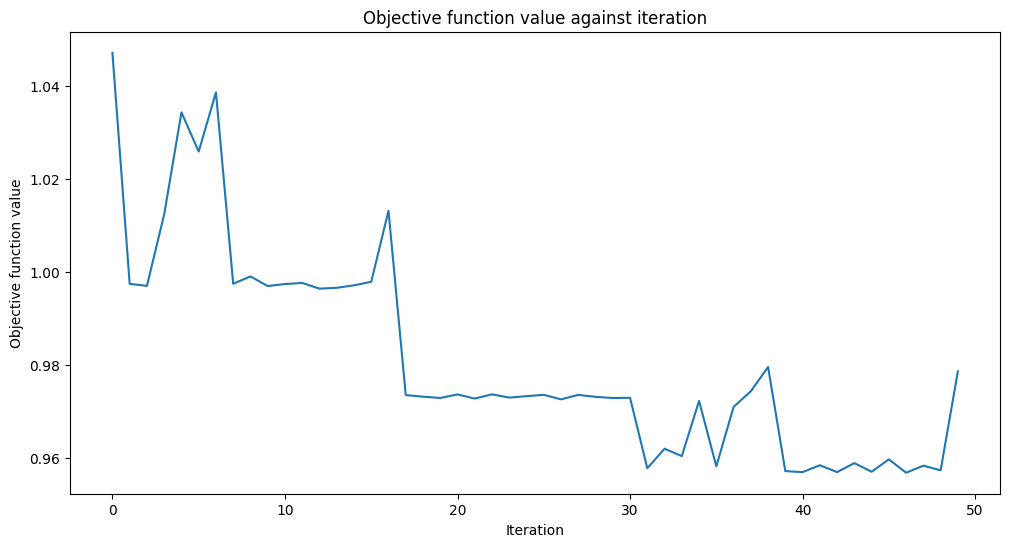

Quantum VQC on the training dataset: 0.63
Quantum VQC on the test dataset:     0.56
Runtime:                             23800.56


In [ ]:
objective_func_vals = []
        
vqc_2 = VQC(
    sampler=sampler,
    feature_map=zz_feature_map(5, 5),
    ansatz=hardware_efficient(5, 2),
    optimizer=COBYLA(maxiter=50),
    callback=callback_graph,
)

start = time.time()
vqc_2.fit(X_train_q, y_train.array)
elapsed = time.time() - start

train_score_q2 = vqc_2.score(X_train_q, y_train)
test_score_q2 = vqc_2.score(X_test_q, y_test)

print(f"Quantum VQC on the training dataset: {train_score_q2:.2f}")
print(f"Quantum VQC on the test dataset:     {test_score_q2:.2f}")
print(f"Runtime:                             {elapsed:.2f}")

Trained during the day, I believe the inflated time is due to the laptop sleeping inbetween lectures.. (approx 6.5 hours total) which doesn't even beat the majority class baseline

Circuit was very shallow (2 layers and only 50 iterations) which motivated the decision for trial pruning in main grid search seen in section 7 below.

## 6. Smoke Test (before main Grid Search)

A reduced grid (2 feature maps, 2 ansätze, 20 iterations) run before the overnight
full grid search. Mainly used to catch any config bugs or discard poor-performing FM/ansatz pairings.

In [ ]:
def trainQNN(featuremap, ansatz, optimiser, training, training_Y,
             testing, testing_Y, sampler_to_use, showGraph=True):
    loss_history = []
 
    def cb(*args):
        loss = args[1] if len(args) == 2 else args[2] # handle COBYLA and SPSA
        loss_history.append(float(loss))
 
        if showGraph:
            clear_output(wait=True)
            plt.title("Objective function value against iteration")
            plt.xlabel("Iteration")
            plt.ylabel("Objective function value")
            plt.plot(range(len(loss_history)), loss_history)
            plt.show()
 
    vqc = VQC(
        sampler=sampler_to_use,
        feature_map=featuremap,
        ansatz=ansatz,
        optimizer=optimiser,
        callback=cb,
    )
 
    start = time.time()
    vqc.fit(training, training_Y.array)
    elapsed = time.time() - start
 
    train_score = vqc.score(training, training_Y)
    test_score  = vqc.score(testing, testing_Y)
    parameters  = vqc.circuit.num_parameters
    best_loss   = min(loss_history) if loss_history else float("inf")
 
    return train_score, test_score, elapsed, parameters, best_loss

In [ ]:
# run smoke test before overnight
smoke_results, smoke_shallow, smoke_poor = [], [], set()

# 2 feature maps, 2 ansatze, 1 optimiser, 2 layer counts, COBYLA and SPSA
smoke_fmaps    = [angle_encode_features, z_feature_map]
smoke_ansatze  = [real_amplitudes, eff_su2]
smoke_optims   = [COBYLA, SPSA]
smoke_layers   = [2, 3]
smoke_maxiter  = 20 
WARMUP, QUANT  = 2, 0.75 # prune after 2 warmup trials, top 25% loss

for optim in smoke_optims:
    for f_map in smoke_fmaps:
        for ansatz in smoke_ansatze:
            for l in smoke_layers:
                family = (f_map.__name__, ansatz.__name__)
                if family in smoke_poor and l > smoke_layers[0]:
                    print(f"{f_map.__name__}+{ansatz.__name__}({l}) SKIPPED")
                    smoke_results.append({"trial": f"{f_map.__name__}+{ansatz.__name__}({l})", "test_acc": None})
                    continue
                
                # SPSA does 2 evals per iteration
                maxiter = smoke_maxiter // 2 if optim.__name__ == "SPSA" else smoke_maxiter
 
                train_acc, test_acc, r, p, best_loss = trainQNN(
                    f_map(5, 5), ansatz(5, l), optim(maxiter=maxiter),
                    X_train_q, Y_train, X_test_q, Y_test, sampler, showGraph=False)
 
                print(f"{f_map.__name__}+{ansatz.__name__}({l} w/{optim.__name__}) -> "
                      f"test={test_acc:.2f}  best_loss={best_loss:.3f}  time={r:.1f}s  params={p}")
                smoke_results.append({"trial": f"{f_map.__name__}+{ansatz.__name__}({l})",
                                      "optimiser": optim.__name__,
                                      "test_acc": test_acc, "best_loss": best_loss,
                                      "runtime": r, "params": p})
 
                if l == smoke_layers[0]:
                    smoke_shallow.append(best_loss)
                    if len(smoke_shallow) >= WARMUP:
                        thr = np.quantile(smoke_shallow, QUANT)
                        if best_loss > thr:
                            smoke_poor.add(family)
                            print(f" : marked poor (loss {best_loss:.3f} > {thr:.3f})")

print("\nSmoke test summary:")
print(pd.DataFrame(smoke_results))
print(f"\nFamilies pruned: {smoke_poor}")

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


angle_encode_features+real_amplitudes(2 w/COBYLA) -> test=0.58  best_loss=0.971  time=100.5s  params=15


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


angle_encode_features+real_amplitudes(3 w/COBYLA) -> test=0.56  best_loss=0.933  time=119.2s  params=20


...

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


angle_encode_features+eff_su2(2 w/SPSA) -> test=0.55  best_loss=0.992  time=474.1s  params=15
 : marked poor (loss 0.992 > 0.975)
angle_encode_features+eff_su2(3) SKIPPED


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


z_feature_map+real_amplitudes(2 w/SPSA) -> test=0.55  best_loss=0.957  time=427.0s  params=15
z_feature_map+real_amplitudes(3) SKIPPED


KeyboardInterrupt: 

Interrupted smoke test a bit early, SPSA optimiser was taking too long (cut from the main grid search as a result).

## 7. Full Grid Search

COBYLA only (iterations=50), layers=[2,3,4]

Naive approach:
- 5 features mapped to 5 qubits
- All Pauli-Y rotations

Feature Maps:
- Angle encoding
- Z feature map
- ZZ feature map
- Pauli rotation feature map

Ansätze:
- Real Amplitudes
- Efficient SU2
- Hardware Efficient
- Quantum Convolutional
- Swap Ansatz

Grid search does a sweep of 4 feature maps, 5 ansätze, 3 layer depths (2,3,4). COBYLA optimiser is used with iterations set at 50.

Tried to improve runtime of grid search by using a pruning strategy losely based on the Optuna library (https://github.com/optuna/optuna-examples/tree/main) which I had used in other ML modules.

Basic pruning logic: after at least 4 wamrup trials completed (with 2 ansatz layers), any feature map/ansatz pairing whose loss is larger than the running average by more than 2 standard deviations is marked poor and skipped for larger layer counts.

This allows more time intensive / deeper layer trials for certain pairings to be skipped. Results are checkpointed to CSV after each trial in case of any crashes or timeouts.


In [ ]:
search_results, shallow_losses, poor_families = [], [], set()

feature_map_list = [angle_encode_features, z_feature_map, zz_feature_map, pauli_feature_map]
ansatz_list = [real_amplitudes, eff_su2, hardware_efficient, quantum_convolutional, swap_ansatz]
optimizer_list = [COBYLA]

n_iter = 50
layers_ansatz = [2, 3, 4]
WARMUP, SIGMA = 4, 2   # prune families outside 95% interval of mean, 4 warmup trials

for optim in optimizer_list:
    for f_map in feature_map_list:
        for ansatz in ansatz_list:
            for l in layers_ansatz:
                family = (f_map.__name__, ansatz.__name__)
                if family in poor_families and l > layers_ansatz[0]:
                    print(f"{f_map.__name__}+{ansatz.__name__}({l} w/{optim.__name__}) SKIPPED")
                    search_results.append({"trial": f"{f_map.__name__}+{ansatz.__name__}({l})",
                                           "Feature Map": f_map.__name__,
                                           "Ansatz": ansatz.__name__,
                                           "Layers": l,
                                           "Optimiser": optim.__name__,
                                           "Train Acc": None, "Test Acc": None,
                                           "Runtime": 0, "Params": None, "Best Loss": None})
                    continue

                maxiter = n_iter

                train_acc, test_acc, r, p, best_loss = trainQNN(
                    f_map(5, 5), ansatz(5, l), optim(maxiter=maxiter),
                    X_train_q, Y_train, X_test_q, Y_test, sampler, showGraph=False)

                print(f"{f_map.__name__}+{ansatz.__name__}({l} w/{optim.__name__}) -> "
                      f"test={test_acc:.2f}  best_loss={best_loss:.3f}  time={r:.1f}s  params={p}")
                search_results.append({"trial": f"{f_map.__name__}+{ansatz.__name__}({l})",
                                       "Feature Map": f_map.__name__,
                                       "Ansatz": ansatz.__name__,
                                       "Layers": l,
                                       "Optimiser": optim.__name__,
                                       "Train Acc": train_acc, "Test Acc": test_acc,
                                       "Runtime": r, "Params": p, "Best Loss": best_loss})

                if l == layers_ansatz[0]:
                    shallow_losses.append(best_loss)
                    if len(shallow_losses) >= WARMUP:
                        mean = np.mean(shallow_losses)
                        std  = np.std(shallow_losses)
                        if best_loss > mean + SIGMA * std:
                            poor_families.add(family)
                            print(f" : marked poor (loss {best_loss:.3f} > {mean + SIGMA*std:.3f})")

                # save after each trial in case crash / timeout
                pd.DataFrame(search_results).to_csv("model_outputs/gridsearch_results.csv", index=False)

print("\nGrid search summary:")
search_results_df = pd.DataFrame(search_results)
print(search_results_df)
print(f"\nFamilies pruned: {poor_families}")
search_results_df

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


angle_encode_features+real_amplitudes(2 w/COBYLA) -> test=0.57  best_loss=0.966  time=219.1s  params=15


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


angle_encode_features+real_amplitudes(3 w/COBYLA) -> test=0.58  best_loss=0.942  time=231.9s  params=20


...

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


pauli_feature_map+swap_ansatz(2 w/COBYLA) -> test=0.55  best_loss=0.940  time=213.1s  params=23


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


pauli_feature_map+swap_ansatz(3 w/COBYLA) -> test=0.61  best_loss=0.914  time=235.0s  params=27
pauli_feature_map+swap_ansatz(4 w/COBYLA) -> test=0.56  best_loss=0.897  time=255.6s  params=31

Grid search summary:
                                             trial            Feature Map  \
0         angle_encode_features+real_amplitudes(2)  angle_encode_features   
1         angle_encode_features+real_amplitudes(3)  angle_encode_features   
2         angle_encode_features+real_amplitudes(4)  angle_encode_features   
3                 angle_encode_features+eff_su2(2)  angle_encode_features   
4                 angle_encode_features+eff_su2(3)  angle_encode_features   
5                 angle_encode_features+eff_su2(4)  angle_encode_features   
6      angle_encode_features+hardware_efficient(2)  angle_encode_features   
7      angle_encode_features+hardware_efficient(3)  angle_encode_features   
8      angle_encode_features+hardware_efficient(4)  angle_encode_features   
9   angle_encode

,trial,Feature Map,Ansatz,Layers,Optimiser,Train Acc,Test Acc,Runtime,Params,Best Loss
0,angle_encode_features+real_amplitudes(2),angle_encode_features,real_amplitudes,2,COBYLA,0.606,0.573585,219.115752,15.0,0.965634
1,angle_encode_features+real_amplitudes(3),angle_encode_features,real_amplitudes,3,COBYLA,0.640,0.577358,231.941331,20.0,0.942489
2,angle_encode_features+real_amplitudes(4),angle_encode_features,real_amplitudes,4,COBYLA,0.654,0.600000,253.311331,25.0,0.920692
3,angle_encode_features+eff_su2(2),angle_encode_features,eff_su2,2,COBYLA,0.596,0.622642,187.724000,15.0,0.962945
4,angle_encode_features+eff_su2(3),angle_encode_features,eff_su2,3,COBYLA,0.668,0.566038,238.259613,20.0,0.884818
5,angle_encode_features+eff_su2(4),angle_encode_features,eff_su2,4,COBYLA,0.626,0.626415,244.012976,25.0,0.905910
6,angle_encode_features+hardware_efficient(2),angle_encode_features,hardware_efficient,2,COBYLA,0.554,0.581132,215.628381,35.0,0.980069
7,angle_encode_features+hardware_efficient(3),angle_encode_features,hardware_efficient,3,COBYLA,0.630,0.569811,240.649071,50.0,0.911115
8,angle_encode_features+hardware_efficient(4),angle_encode_features,hardware_efficient,4,COBYLA,0.644,0.611321,328.683256,65.0,0.918258
9,angle_encode_features+quantum_convolutional(2),angle_encode_features,quantum_convolutional,2,COBYLA,0.610,0.558491,228.035129,31.0,0.951496


### Grid search results

Angle encoding combined with EfficientSU2 (4 layers) produced the highest test accuracy.

In [22]:
print(search_results_df.sort_values("Test Acc", ascending=False).head(10))

                                          trial            Feature Map  \
5              angle_encode_features+eff_su2(4)  angle_encode_features   
3              angle_encode_features+eff_su2(2)  angle_encode_features   
48                 pauli_feature_map+eff_su2(2)      pauli_feature_map   
29                 z_feature_map+swap_ansatz(4)          z_feature_map   
8   angle_encode_features+hardware_efficient(4)  angle_encode_features   
18                     z_feature_map+eff_su2(2)          z_feature_map   
58             pauli_feature_map+swap_ansatz(3)      pauli_feature_map   
47         pauli_feature_map+real_amplitudes(4)      pauli_feature_map   
20                     z_feature_map+eff_su2(4)          z_feature_map   
19                     z_feature_map+eff_su2(3)          z_feature_map   

                Ansatz  Layers Optimiser  Train Acc  Test Acc     Runtime  \
5              eff_su2       4    COBYLA      0.626  0.626415  244.012976   
3              eff_su2       2 

### Tried increasing EffSU2 ansatz to 6 layers and training for comparison to 4 layer circuit

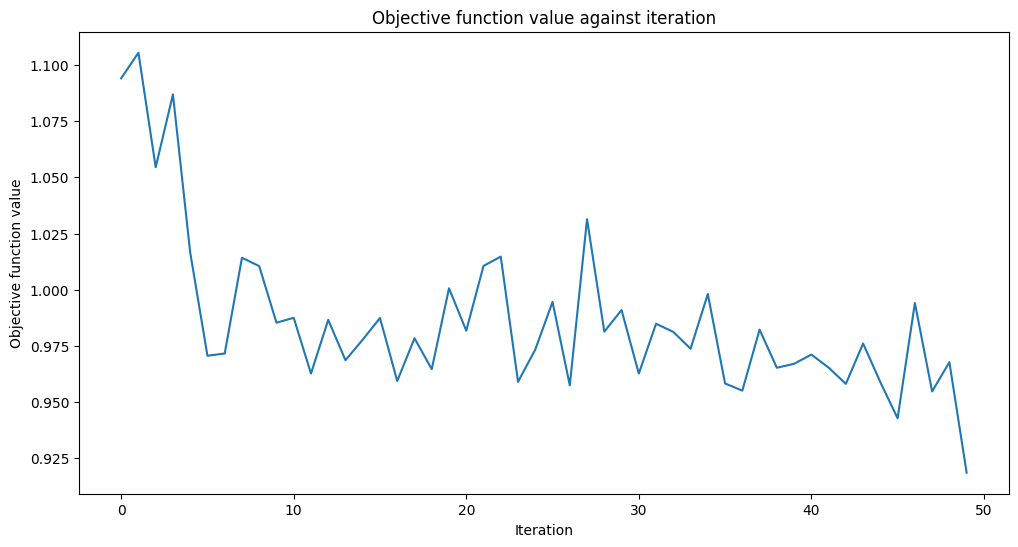

angle_encode_features+eff_su2(6 w/COBYLA) -> test=0.63  six_layer_loss=0.919  time=356.3s  params=35


In [23]:
train_acc, test_acc, r, p, six_layer_loss = trainQNN(
                    angle_encode_features(5, 5), eff_su2(5, 6), COBYLA(maxiter=50),
                    X_train_q, Y_train, X_test_q, Y_test, sampler, showGraph=True)

print(f"{angle_encode_features.__name__}+{eff_su2.__name__}({6} w/{COBYLA.__name__}) -> "
                      f"test={test_acc:.2f}  six_layer_loss={six_layer_loss:.3f}  time={r:.1f}s  params={p}")

### Increasing EffSU2 ansatz to 8 layers for comparison

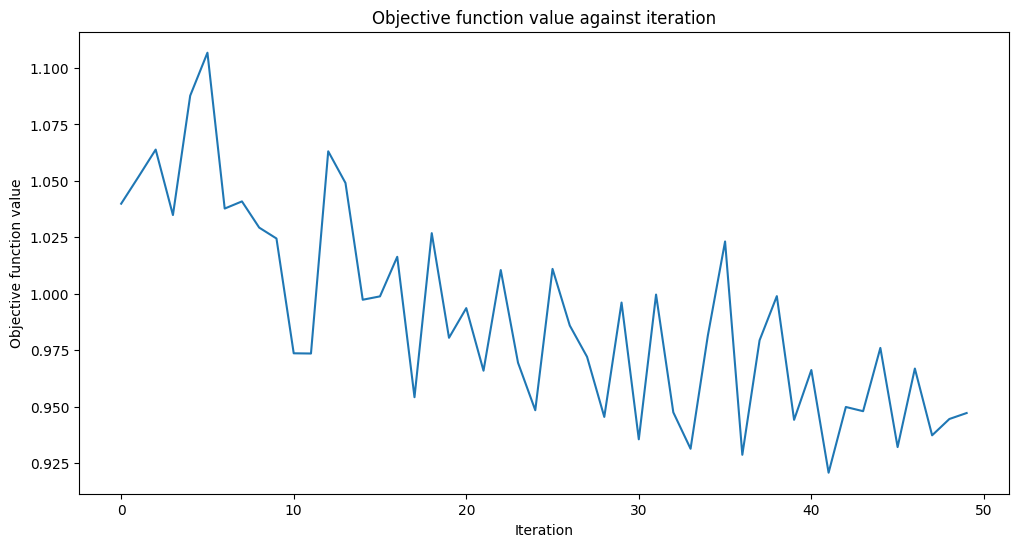

angle_encode_features+eff_su2(8 w/COBYLA) -> test=0.58  eight_layer_loss=0.921  time=425.1s  params=45


In [24]:
train_acc, test_acc, r, p, eight_layer_loss = trainQNN(
                    angle_encode_features(5, 5), eff_su2(5, 8), COBYLA(maxiter=50),
                    X_train_q, Y_train, X_test_q, Y_test, sampler, showGraph=True)

print(f"{angle_encode_features.__name__}+{eff_su2.__name__}({8} w/{COBYLA.__name__}) -> "
                      f"test={test_acc:.2f}  eight_layer_loss={eight_layer_loss:.3f}  time={r:.1f}s  params={p}")

As seen above, deeper circuits (6, 8 layers) did not improve on 4 layers and unfortunately took longer to train. The flat or worsening loss is the barren plateau phenomenon as described in "Barren plateaus in quantum neural network training landscapes" McClean et al., 2018. 

| Layers | Runtime | Loss  | Test Acc | Params |
|--------|---------|-------|----------|--------|
| 4      | 4 min   | 0.906 | 0.63     | 25  |
| 6      | 6 min   | 0.919 | 0.63     | 35   |
| 8      | 7 min   | 0.921 | 0.58     | 45   |

## 8. Further training: angle encoding / EfficientSU2 4 layers

The best config from the grid search is retrained with 150 iterations to allow for more convergence

In [9]:
# new function returns vqc
def trainQNNFurther(featuremap, ansatz, optimiser, training, training_Y,
             testing, testing_Y, sampler_to_use, showGraph=True):
    loss_history = []
 
    def cb(*args):
        loss = args[1] if len(args) == 2 else args[2]
        loss_history.append(float(loss))
 
        if showGraph:
            clear_output(wait=True)
            plt.title("Objective function value against iteration")
            plt.xlabel("Iteration")
            plt.ylabel("Objective function value")
            plt.plot(range(len(loss_history)), loss_history)
            plt.show()
 
    vqc = VQC(
        sampler=sampler_to_use,
        feature_map=featuremap,
        ansatz=ansatz,
        optimizer=optimiser,
        callback=cb,
    )
 
    start = time.time()
    vqc.fit(training, training_Y.array)
    elapsed = time.time() - start
 
    train_score = vqc.score(training, training_Y)
    test_score  = vqc.score(testing, testing_Y)
    parameters  = vqc.circuit.num_parameters
    best_loss   = min(loss_history) if loss_history else float("inf")
 
    return train_score, test_score, elapsed, parameters, best_loss, vqc

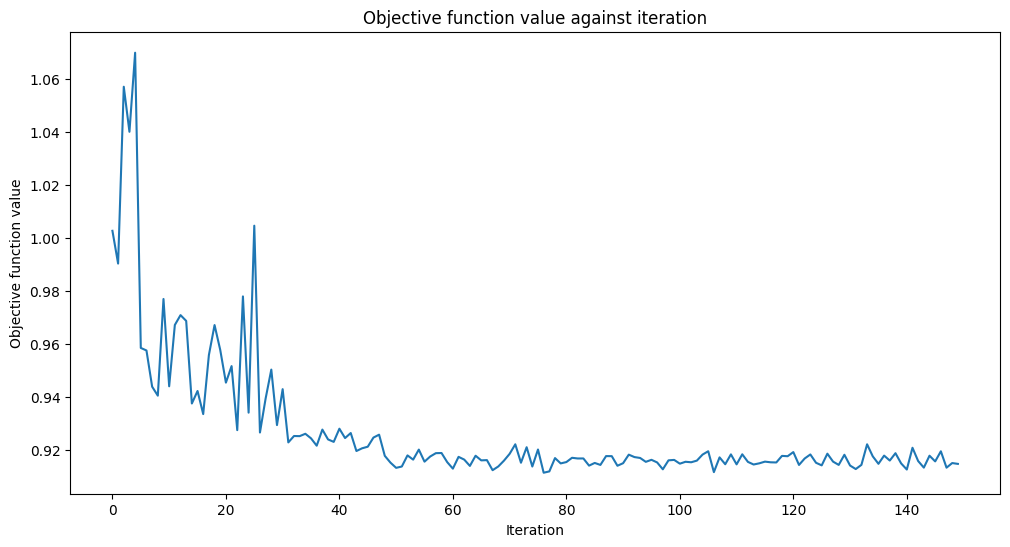

angle_encode_features+eff_su2(4 w/COBYLA) -> test=0.59  four_layer_loss=0.912  time=1367.8s  params=25


In [ ]:
train_acc, test_acc, r, p, four_layer_loss, model = trainQNNFurther(
                    angle_encode_features(5, 5), eff_su2(5, 4), COBYLA(maxiter=150),
                    X_train_q, Y_train, X_test_q, Y_test, sampler, showGraph=True)
print(f"{angle_encode_features.__name__}+{eff_su2.__name__}({4} w/{COBYLA.__name__}) -> "
                      f"test={test_acc:.2f}  four_layer_loss={four_layer_loss:.3f}  time={r:.1f}s  params={p}")
# weights
weights = model.weights
np.save("best_grid_qnn_weights.npy", weights)

meta = {
    "feature_map": "angle_encode_features",
    "feature_map_reps": 5,
    "ansatz": "eff_su2",
    "ansatz_reps": 4,
    "num_qubits": 5,
    "optimizer": "COBYLA",
    "maxiter": 150
}
# model metadata
with open("qnn_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

In [39]:
y_pred = model.predict(X_test_q.values)
print(f"Test Accuracy: {accuracy_score(Y_test, y_pred):.4f}")
print(f"Macro F1: {f1_score(Y_test, y_pred, average='macro'):.4f}")
print(classification_report(Y_test, y_pred, target_names=['Fooled', 'Correct']))

Test Accuracy: 0.5547
Macro F1: 0.5376
              precision    recall  f1-score   support

      Fooled       0.59      0.66      0.63       149
     Correct       0.49      0.41      0.45       116

    accuracy                           0.55       265
   macro avg       0.54      0.54      0.54       265
weighted avg       0.55      0.55      0.55       265



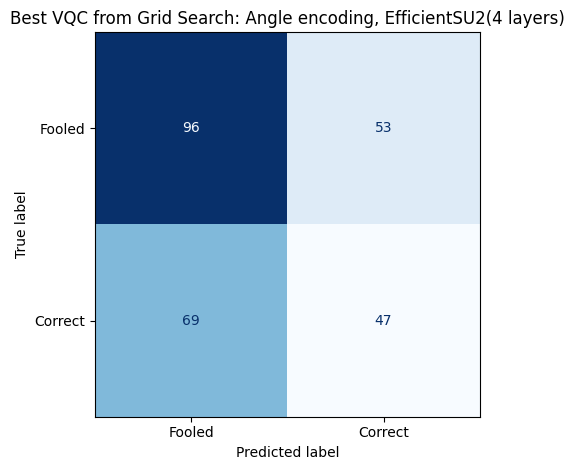

In [31]:
cm = confusion_matrix(Y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Fooled', 'Correct']).plot(cmap='Blues', colorbar=False)
plt.title('Best VQC from Grid Search: Angle encoding, EfficientSU2(4 layers)')
plt.tight_layout()
plt.show()

### Why further training did not reproduce the grid search accuracy

The grid search (50 iterations) reported 0.63 test accuracy but retraining with 150
iterations only scored 0.55. COBYLA is sensitive to the initial point. The grid search result likely caught a favourable local minimum that was not reproducible as I forgot to save the initial point and the retraining would have started from a different random initialisation.

## 9. Build a custom ansatz. Entangle features: player_fool_rate and opponent_avg_detection_rate

Chose to take the two features which are used in computing skill_gap (difference between the defender's fool rate and the opposing team's average detection rate) and build an ansatz using them.

In [ ]:
# qubits 0-1 are features for skill_gap
qml_features_custom = [
    'player_fool_rate', # heavily entangle 
    'opponent_avg_detection_rate', # heavily entangle
    'is_lie',
    'skill_gap',
    'captain_team'
]

mm_scaler = MinMaxScaler()

X_train_custom = pd.DataFrame(
    mm_scaler.fit_transform(X_train[qml_features_custom]),
    columns=qml_features_custom,
    index=X_train.index
)
X_test_custom = pd.DataFrame(
    mm_scaler.transform(X_test[qml_features_custom]),
    columns=qml_features_custom,
    index=X_test.index
)

print("Data setup for new ansatz")

Data setup for new ansatz


### Heavily entangle q0 and q1 (skill_gap features)

In [13]:
# q0 and q1 entangled with 2 qubit block
def skill_gap_ansatz(num_qubits=5, reps=2):
    qc = QuantumCircuit(num_qubits)
    
    params = ParameterVector('θ', (num_qubits + 3) * reps)
    p_idx = 0
    
    for r in range(reps):
        # Y rotations on all qubits
        for i in range(num_qubits):
            qc.ry(params[p_idx], i)
            p_idx += 1
        # q0 and q1
        qc.cx(0, 1)
        qc.rz(params[p_idx], 1); p_idx += 1
        qc.cx(0, 1)
        qc.ry(params[p_idx], 0); p_idx += 1
        qc.ry(params[p_idx], 1); p_idx += 1
        
        qc.cx(1, 2)
        qc.cx(2, 3)
        qc.cx(3, 4)
    
    return qc

test_ansatz = skill_gap_ansatz(5, reps=2)
print(f"New ansatz parameters: {test_ansatz.num_parameters}")
print(f"New ansatz depth: {test_ansatz.decompose().depth()}")

New ansatz parameters: 16
New ansatz depth: 14


### Visualise custom ansatz circuit

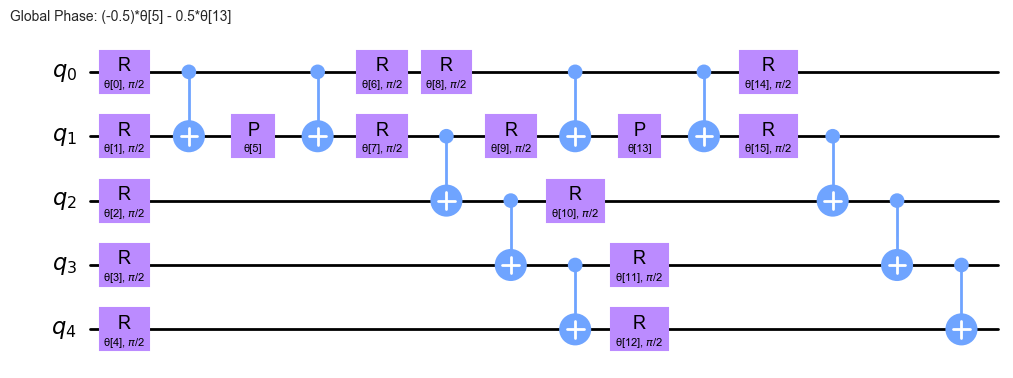

In [ ]:
# circuit of new ansatz
test_ansatz.decompose().draw(output="mpl", style="clifford", fold=20)

## 10. Train skill_gap custom ansatz (2 layers) using angle encoding

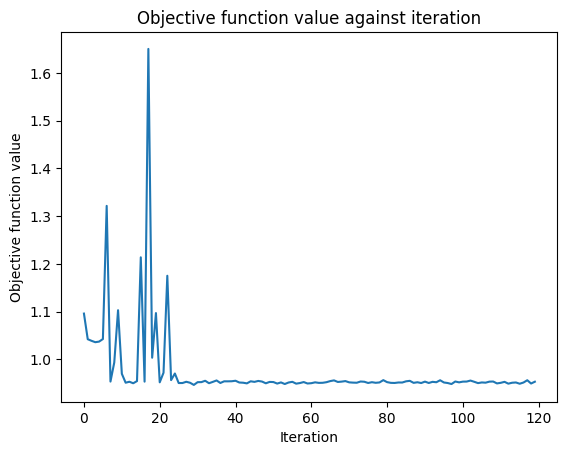

angle_encode_features+skill_gap_ansatz(2 w/COBYLA) -> test=0.55  four_layer_loss=0.947  time=547.2s  params=21


In [ ]:
sampler = StatevectorSampler()

train_acc, test_acc, r, p, four_layer_loss, custom_ansatz_model = trainQNNFurther(
                    angle_encode_features(5, 5), skill_gap_ansatz(5, 2), COBYLA(maxiter=120),
                    X_train_custom, Y_train, X_test_custom, Y_test, sampler, showGraph=True)
print(f"{angle_encode_features.__name__}+{skill_gap_ansatz.__name__}({2} w/{COBYLA.__name__}) -> "
                      f"test={test_acc:.2f}  four_layer_loss={four_layer_loss:.3f}  time={r:.1f}s  params={p}")

# weights
custom_ansatz_weights = custom_ansatz_model.weights
np.save("custom_ansatz_qnn_weights.npy", custom_ansatz_weights)

In [23]:
y_pred = custom_ansatz_model.predict(X_test_custom)
print(f"Test Accuracy: {accuracy_score(Y_test, y_pred):.4f}")
print(f"Macro F1: {f1_score(Y_test, y_pred, average='macro'):.4f}")
print(classification_report(Y_test, y_pred, target_names=['Fooled', 'Correct']))

Test Accuracy: 0.5547
Macro F1: 0.5159
              precision    recall  f1-score   support

      Fooled       0.58      0.74      0.65       149
     Correct       0.49      0.31      0.38       116

    accuracy                           0.55       265
   macro avg       0.53      0.53      0.52       265
weighted avg       0.54      0.55      0.53       265



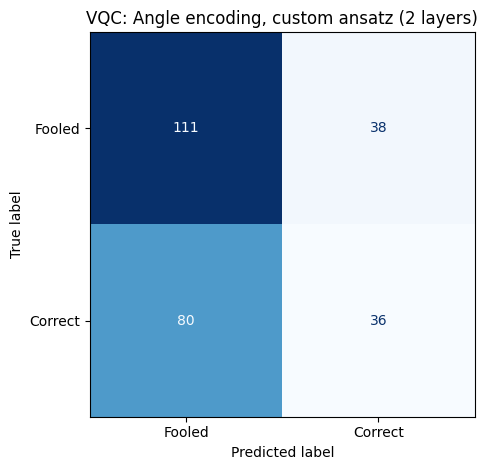

In [24]:
cm = confusion_matrix(Y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Fooled', 'Correct']).plot(cmap='Blues', colorbar=False)
plt.title('VQC: Angle encoding, custom ansatz (2 layers)')
plt.tight_layout()
plt.show()

## 11. New Feature Set Experiment

Replaced the top 5 importance features with an alternative set to test whether a different
combination could perform better. Results were unfortunately worse than the initial feature set which reflects the relevance of feature ranking/importance from the classical notebook

In [16]:
new_5_features = [
    'player_fool_rate',
    'opponent_avg_detection_rate',
    'statement_index_normalised',
    'prior_appearances',
    'is_lie'
]

X_train_5 = X_train[new_5_features]
X_test_5 = X_test[new_5_features]

# MinMax scale, fit on train only
mm_scaler = MinMaxScaler()
X_train_q_new = pd.DataFrame(mm_scaler.fit_transform(X_train_5), columns=new_5_features, index=X_train_5.index)
X_test_q_new = pd.DataFrame(mm_scaler.transform(X_test_5), columns=new_5_features, index=X_test_5.index)

Y_train = y_train
Y_test = y_test

NUM_QUBITS = len(new_5_features)

print(f"Features: {new_5_features}")
print(f"Qubits: {NUM_QUBITS}")
print(f"Training: {len(X_train_q_new)}, Test: {len(X_test_q_new)}")
print(f"Majority baseline (test): {max(Y_test.value_counts(normalize=True)):.4f}")

Features: ['player_fool_rate', 'opponent_avg_detection_rate', 'statement_index_normalised', 'prior_appearances', 'is_lie']
Qubits: 5
Training: 500, Test: 265
Majority baseline (test): 0.5623


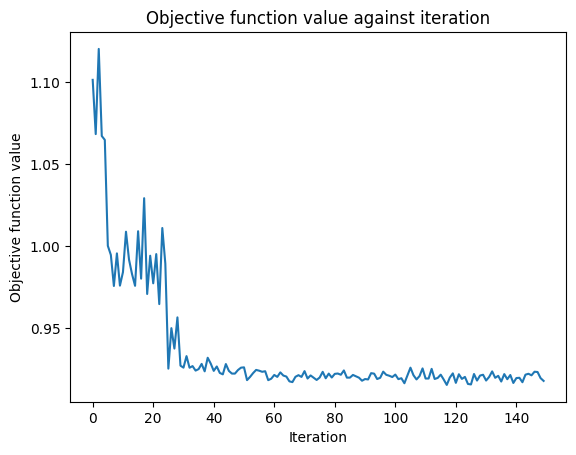

angle_encode_features+eff_su2(4 w/COBYLA) -> test=0.51  loss=0.915  time=836.3s  params=25


In [17]:
train_acc, test_acc, r, p, loss, new_featureset_model = trainQNNFurther(
                    angle_encode_features(5, 5), eff_su2(5, 4), COBYLA(maxiter=150),
                    X_train_q_new, Y_train, X_test_q_new, Y_test, sampler, showGraph=True)
print(f"{angle_encode_features.__name__}+{eff_su2.__name__}({4} w/{COBYLA.__name__}) -> "
                      f"test={test_acc:.2f}  loss={loss:.3f}  time={r:.1f}s  params={p}")

# save weights
new_featureset_weights = new_featureset_model.weights
np.save("new_featureset_qnn_weights.npy", new_featureset_weights)

In [18]:
print(f"Quantum VQC on the training dataset: {train_acc:.2f}")
print(f"Quantum VQC on the test dataset: {test_acc:.2f}")
print(f"Runtime: {r:.2f}")
print(f"Parameters: {p}")

Quantum VQC on the training dataset: 0.65
Quantum VQC on the test dataset: 0.51
Runtime: 836.33
Parameters: 25


In [40]:
y_pred = new_featureset_model.predict(X_test_q_new.values)
print(f"Test Accuracy: {accuracy_score(Y_test, y_pred):.4f}")
print(f"Macro F1:      {f1_score(Y_test, y_pred, average='macro'):.4f}")
print(classification_report(Y_test, y_pred, target_names=['Fooled', 'Correct']))

Test Accuracy: 0.5170
Macro F1:      0.5119
              precision    recall  f1-score   support

      Fooled       0.57      0.55      0.56       149
     Correct       0.45      0.47      0.46       116

    accuracy                           0.52       265
   macro avg       0.51      0.51      0.51       265
weighted avg       0.52      0.52      0.52       265



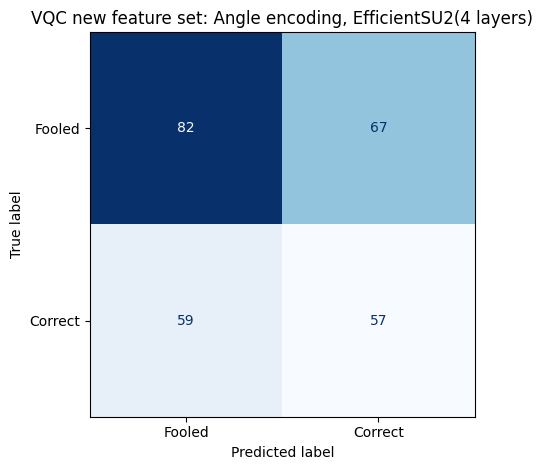

In [22]:
cm = confusion_matrix(Y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Fooled', 'Correct']).plot(cmap='Blues', colorbar=False)
plt.title('VQC new feature set: Angle encoding, EfficientSU2(4 layers)')
plt.tight_layout()
plt.show()

## 12. Throwing the Kitchen Sink: Build QSVM

A quantum kernel replaces the RBF kernel in a classical SVM with a quantum fidelity
kernel computed from circuit measurements.

Below implementation is heavily based on: Qiskit Machine Learning tutorial 08: Quantum Kernel Training
(https://qiskit-community.github.io/qiskit-machine-learning/tutorials/08_quantum_kernel_trainer.html)

In [ ]:
# subsample training set to 50 samples
# kernel matrix has O(n ^ 2) evaluations
X_train_subsample, y_train_subsample = resample(
    X_train_q.values, Y_train.values,
    n_samples=50, random_state=SEED
)

### Define Quantum feature map

In [58]:
# trainable rotation layer, one param per qubit
training_params = ParameterVector('θ', len(qml_features))
fm_rot = QuantumCircuit(len(qml_features))
for i in range(len(qml_features)):
    fm_rot.ry(training_params[i], i)

# compose with angle encoding feature map
fm_full = fm_rot.compose(angle_encode_features(len(qml_features), len(qml_features)))
print(fm_full.decompose().draw())
print(f"Trainable parameters: {list(training_params)}")

     ┌─────────────┐┌───────────────┐                    
q_0: ┤ R(θ[0],π/2) ├┤ R(π*x[0],π/2) ├──■─────────────────
     ├─────────────┤├───────────────┤┌─┴─┐               
q_1: ┤ R(θ[1],π/2) ├┤ R(π*x[1],π/2) ├┤ X ├──■────────────
     ├─────────────┤├───────────────┤└───┘┌─┴─┐          
q_2: ┤ R(θ[2],π/2) ├┤ R(π*x[2],π/2) ├─────┤ X ├──■───────
     ├─────────────┤├───────────────┤     └───┘┌─┴─┐     
q_3: ┤ R(θ[3],π/2) ├┤ R(π*x[3],π/2) ├──────────┤ X ├──■──
     ├─────────────┤├───────────────┤          └───┘┌─┴─┐
q_4: ┤ R(θ[4],π/2) ├┤ R(π*x[4],π/2) ├───────────────┤ X ├
     └─────────────┘└───────────────┘               └───┘
Trainable parameters: [ParameterVectorElement(θ[0]), ParameterVectorElement(θ[1]), ParameterVectorElement(θ[2]), ParameterVectorElement(θ[3]), ParameterVectorElement(θ[4])]


In [59]:
class QKTCallback:
    def __init__(self):
        self._loss = []

    def callback(self, x0, x1=None, x2=None, x3=None, x4=None):
        self._loss.append(x2)

    def plot(self):
        plt.plot(range(1, len(self._loss) + 1), self._loss)
        plt.xlabel('Iteration')
        plt.ylabel('Loss')
        plt.title('Quantum Kernel Training Loss')
        plt.tight_layout()
        plt.show()

cb_qkt = QKTCallback()

In [60]:
# fidelity kernel + trainer
sampler = StatevectorSampler()
fidelity = ComputeUncompute(sampler=sampler)

qkernel = TrainableFidelityQuantumKernel(
    fidelity=fidelity,
    feature_map=fm_full,
    training_parameters=training_params
)

spsa = SPSA(maxiter=20, learning_rate=0.05, perturbation=0.05, callback=cb_qkt.callback)

qkt = QuantumKernelTrainer(
    quantum_kernel=qkernel,
    loss='svc_loss',
    optimizer=spsa,
    initial_point=[np.pi / 2]*len(qml_features)
)

{   'optimal_circuit': None,
    'optimal_parameters': {   ParameterVectorElement(θ[1]): np.float64(1.799323824490033),
                              ParameterVectorElement(θ[4]): np.float64(1.6139126539775948),
                              ParameterVectorElement(θ[3]): np.float64(1.692317571424164),
                              ParameterVectorElement(θ[2]): np.float64(1.6192732119273732),
                              ParameterVectorElement(θ[0]): np.float64(1.3726380791013018)},
    'optimal_point': array([1.37263808, 1.79932382, 1.61927321, 1.69231757, 1.61391265]),
    'optimal_value': np.float64(34.99508593873723),
    'optimizer_evals': 60,
    'optimizer_result': None,
    'optimizer_time': None,
    'quantum_kernel': <qiskit_machine_learning.kernels.trainable_fidelity_quantum_kernel.TrainableFidelityQuantumKernel object at 0x0000029E4948AEA0>}
Training time: 733.0s


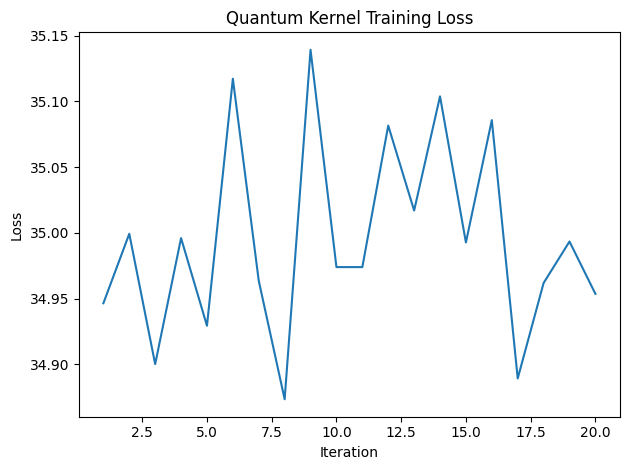

In [61]:
# train kernel
start = time.time()
qkt_result = qkt.fit(X_train_subsample, y_train_subsample)
elapsed = time.time() - start

optimized_kernel = qkt_result.quantum_kernel
print(qkt_result)
print(f"Training time: {elapsed:.1f}s")
cb_qkt.plot()

In [ ]:
np.save('qsvm_optimal_params.npy', qkt_result.optimal_point)

In [62]:
# fit QSVC and evaluate
qsvc = QSVC(quantum_kernel=optimized_kernel)
qsvc.fit(X_train_subsample, y_train_subsample)
y_pred_qsvc = qsvc.predict(X_test_q.values)

print(f"Test Accuracy: {accuracy_score(Y_test, y_pred_qsvc):.4f}")
print(f"Macro F1: {f1_score(Y_test, y_pred_qsvc, average='macro'):.4f}")
print(classification_report(Y_test, y_pred_qsvc, target_names=['Fooled', 'Correct']))

Test Accuracy: 0.5887
Macro F1: 0.5665
              precision    recall  f1-score   support

      Fooled       0.61      0.72      0.66       149
     Correct       0.54      0.41      0.47       116

    accuracy                           0.59       265
   macro avg       0.58      0.57      0.57       265
weighted avg       0.58      0.59      0.58       265



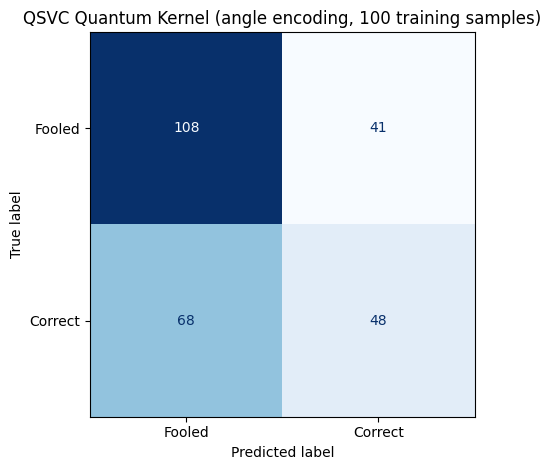

In [63]:
cm = confusion_matrix(Y_test, y_pred_qsvc)
ConfusionMatrixDisplay(cm, display_labels=['Fooled', 'Correct']).plot(cmap='Blues', colorbar=False)
plt.title('QSVC Quantum Kernel (angle encoding, 100 training samples)')
plt.tight_layout()
plt.show()

### 12.2 QSVM: Hyperparameter Tuning of SPSA optimiser

The initial run used standard SPSA settings (learning rate=0.05, perturbation=0.05). Loss curve clearly had no convergence. Second run with larger steps is tested to see if a more stable optimum is found

{   'optimal_circuit': None,
    'optimal_parameters': {   ParameterVectorElement(θ[1]): np.float64(1.6869522873229759),
                              ParameterVectorElement(θ[4]): np.float64(-0.8834247728342159),
                              ParameterVectorElement(θ[3]): np.float64(0.0467733191388664),
                              ParameterVectorElement(θ[2]): np.float64(0.7683614966467633),
                              ParameterVectorElement(θ[0]): np.float64(3.038546583825381)},
    'optimal_point': array([ 3.03854658,  1.68695229,  0.7683615 ,  0.04677332, -0.88342477]),
    'optimal_value': np.float64(34.842410678427235),
    'optimizer_evals': 150,
    'optimizer_result': None,
    'optimizer_time': None,
    'quantum_kernel': <qiskit_machine_learning.kernels.trainable_fidelity_quantum_kernel.TrainableFidelityQuantumKernel object at 0x0000029E38CCF650>}
Training time: 1898.2s


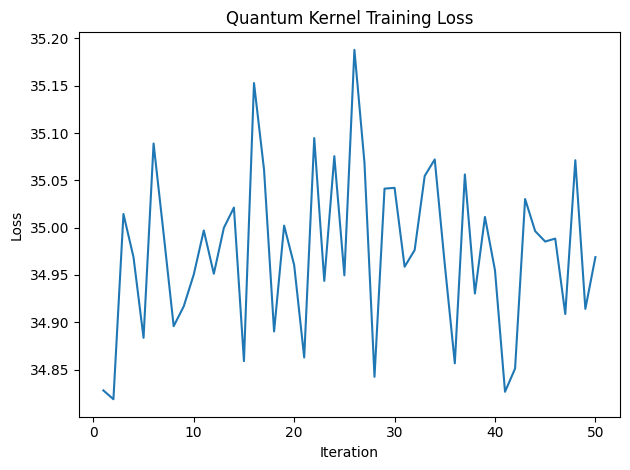

In [65]:
# reset callback
cb_qkt2 = QKTCallback()

# rebuild kernel with same feature map
qkernel2 = TrainableFidelityQuantumKernel(
    fidelity=fidelity,
    feature_map=fm_full,
    training_parameters=training_params
)

spsa2 = SPSA(maxiter=50, learning_rate=0.5, perturbation=0.1, callback=cb_qkt2.callback)

qkt2 = QuantumKernelTrainer(
    quantum_kernel=qkernel2,
    loss='svc_loss',
    optimizer=spsa2,
    initial_point=[np.pi / 2]*len(qml_features)
)

start = time.time()
qkt_result2 = qkt2.fit(X_train_subsample, y_train_subsample)
elapsed = time.time() - start

optimized_kernel2 = qkt_result2.quantum_kernel
print(qkt_result2)
print(f"Training time: {elapsed:.1f}s")
cb_qkt2.plot()

In [73]:
np.save('qsvm2_optimal_params.npy', qkt_result2.optimal_point)

In [66]:
qsvm2 = QSVC(quantum_kernel=optimized_kernel2)
qsvm2.fit(X_train_subsample, y_train_subsample)

y_pred_qsvm2 = qsvm2.predict(X_test_q.values)
print(f"Test Accuracy: {accuracy_score(Y_test, y_pred_qsvm2):.4f}")
print(f"Macro F1: {f1_score(Y_test, y_pred_qsvm2, average='macro'):.4f}")
print(classification_report(Y_test, y_pred_qsvm2, target_names=['Fooled', 'Correct']))

Test Accuracy: 0.5887
Macro F1: 0.5665
              precision    recall  f1-score   support

      Fooled       0.61      0.72      0.66       149
     Correct       0.54      0.41      0.47       116

    accuracy                           0.59       265
   macro avg       0.58      0.57      0.57       265
weighted avg       0.58      0.59      0.58       265



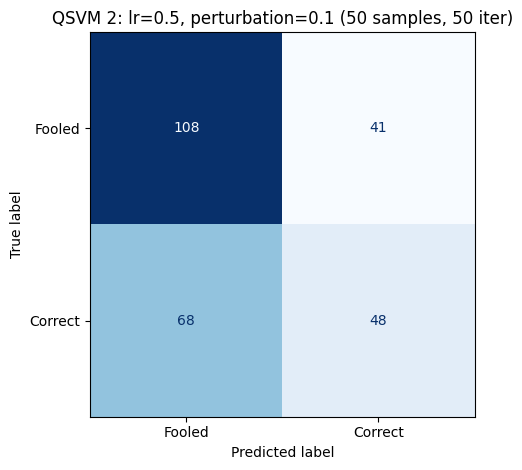

In [67]:
cm = confusion_matrix(Y_test, y_pred_qsvm2)
ConfusionMatrixDisplay(cm, display_labels=['Fooled', 'Correct']).plot(cmap='Blues', colorbar=False)
plt.title('QSVM 2: lr=0.5, perturbation=0.1 (50 samples, 50 iter)')
plt.tight_layout()
plt.show()

### 12.3 QSVM: COBYLA optimiser, 100 training samples

Clearly still no convergence using SPSA, switch to COBYLA and increase sample size.

{   'optimal_circuit': None,
    'optimal_parameters': {   ParameterVectorElement(θ[1]): np.float64(2.6887631326471735),
                              ParameterVectorElement(θ[4]): np.float64(1.480331501568687),
                              ParameterVectorElement(θ[3]): np.float64(1.5097021493978098),
                              ParameterVectorElement(θ[2]): np.float64(2.0384483783762954),
                              ParameterVectorElement(θ[0]): np.float64(1.4339997421382873)},
    'optimal_point': array([1.43399974, 2.68876313, 2.03844838, 1.50970215, 1.4803315 ]),
    'optimal_value': np.float64(61.838355650272824),
    'optimizer_evals': np.int64(43),
    'optimizer_result': None,
    'optimizer_time': None,
    'quantum_kernel': <qiskit_machine_learning.kernels.trainable_fidelity_quantum_kernel.TrainableFidelityQuantumKernel object at 0x0000029E3878D760>}
Training time: 2125.3s


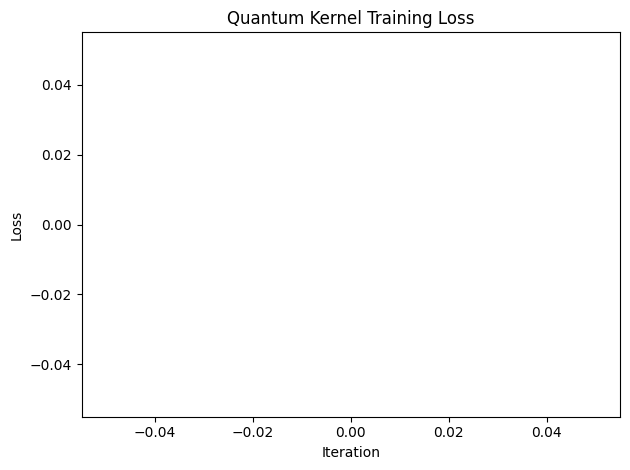

In [70]:
# larger subsample
X_train_sub3, y_train_sub3 = resample(
    X_train_q.values, Y_train.values,
    n_samples=100, random_state=SEED
)

# reset callback
cb_qkt3 = QKTCallback()

# rebuild kernel
qkernel3 = TrainableFidelityQuantumKernel(
    fidelity=fidelity,
    feature_map=fm_full,
    training_parameters=training_params
)

cobyla_optimiser = COBYLA(maxiter=50)

qkt3 = QuantumKernelTrainer(
    quantum_kernel=qkernel3,
    loss='svc_loss',
    optimizer=cobyla_optimiser,
    initial_point=[np.pi/2]*len(qml_features)
)

start = time.time()
qkt_result3 = qkt3.fit(X_train_sub3, y_train_sub3)
elapsed = time.time() - start

optimized_kernel3 = qkt_result3.quantum_kernel
print(qkt_result3)
print(f"Training time: {elapsed:.1f}s")
cb_qkt3.plot()

In [71]:
qsvc3 = QSVC(quantum_kernel=optimized_kernel3)
qsvc3.fit(X_train_sub3, y_train_sub3)

y_pred_qsvc3 = qsvc3.predict(X_test_q.values)
print(f"Test Accuracy: {accuracy_score(Y_test, y_pred_qsvc3):.4f}")
print(f"Macro F1: {f1_score(Y_test, y_pred_qsvc3, average='macro'):.4f}")
print(classification_report(Y_test, y_pred_qsvc3, target_names=['Fooled', 'Correct']))

Test Accuracy: 0.6226
Macro F1: 0.6104
              precision    recall  f1-score   support

      Fooled       0.65      0.71      0.68       149
     Correct       0.58      0.51      0.54       116

    accuracy                           0.62       265
   macro avg       0.61      0.61      0.61       265
weighted avg       0.62      0.62      0.62       265



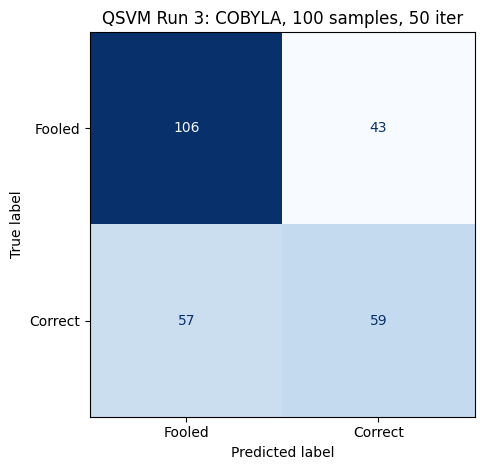

In [72]:
cm = confusion_matrix(Y_test, y_pred_qsvc3)
ConfusionMatrixDisplay(cm, display_labels=['Fooled', 'Correct']).plot(cmap='Blues', colorbar=False)
plt.title('QSVM Run 3: COBYLA, 100 samples, 50 iter')
plt.tight_layout()
plt.show()

#### Save optimal kernel params and the training data subsamples

In [75]:
np.save('qsvm3_optimal_params.npy', qkt_result3.optimal_point)
np.save('model_outputs/qsvc_X_train_sub.npy', X_train_sub3)
np.save('model_outputs/qsvc_y_train_sub.npy', y_train_sub3)

## 13. Summary of QML Experiments

The strongest noiseless VQC result was angle encoding + EfficientSU2 (4 layers, 50 iterations)
at 0.63 accuracy, though this was not reproduced under further training. The most reliable
quantum result is the QSVM (COBYLA, 100 samples) at 0.622 accuracy and 0.610 macro f1 which thankfully matches the classival SVM (rbf kernel) benchmark.

| Model | Test Accuracy | Macro F1 |
|---|---|---|
| Majority baseline | 0.562 | 0.36 |
| Logistic Regression | 0.581 | 0.40 |
| KNN | 0.574 | 0.454 |
| Random Forest | 0.570 | 0.186 |
| XGBoost | 0.543 | 0.339 |
| **SVM (rbf)** | **0.615** | **0.549** |
| VQC standalone (ZZ&HardwareEfficient, 50 iter) | 0.556 | n/a |
| VQC best grid (angle&EffSU2, 4L, 50 iter) | **0.630** | n/a |
| VQC retrained (angle&EffSU2, 4L, 150 iter) | 0.555 | 0.523 |
| VQC custom ansatz (angle & skill_gap, 120 iter) | 0.555 | 0.516 |
| VQC alternative features (angle&EffSU2, 150 iter) | 0.517 | 0.522 |
| **QSVM COBYLA** (100 samples, 50 iter) | **0.622** | **0.610** |

All converged quantum models beat the majority baseline and predicted both classes.
The QSVM (COBYLA, 100 samples) matched the classical SVM on accuracy and exceeded it on the macro f1 score. This result should be taken with a pinch of salt as the kernel was only trained on 100 of
the 500 available training samples. The alternative feature set VQCs produced the weakest
result confirming the importance ranking from the classical notebook. Results from HW inference are in the inference notebook.

-EOF-